In [3]:
import pandas as pd
df_minute = pd.read_csv("E:\\Jupyter\\pollution project\\weather\\minute_weather.csv")
print(df_minute.head(5))
print(df_minute.columns)
print(df_minute.info())
print(df_minute.describe())

   rowID     hpwren_timestamp  air_pressure  air_temp  avg_wind_direction  \
0      0  2011-09-10 00:00:49         912.3     64.76                97.0   
1      1  2011-09-10 00:01:49         912.3     63.86               161.0   
2      2  2011-09-10 00:02:49         912.3     64.22                77.0   
3      3  2011-09-10 00:03:49         912.3     64.40                89.0   
4      4  2011-09-10 00:04:49         912.3     64.40               185.0   

   avg_wind_speed  max_wind_direction  max_wind_speed  min_wind_direction  \
0             1.2               106.0             1.6                85.0   
1             0.8               215.0             1.5                43.0   
2             0.7               143.0             1.2               324.0   
3             1.2               112.0             1.6                12.0   
4             0.4               260.0             1.0               100.0   

   min_wind_speed  rain_accumulation  rain_duration  relative_humidity  
0

In [4]:
df_minute['hpwren_timestamp'] = pd.to_datetime(df_minute['hpwren_timestamp'])
df_minute = df_minute.sort_values('hpwren_timestamp')
df_minute = df_minute.drop_duplicates()
df_minute = df_minute.dropna()
df_minute['hpwren_timestamp'].diff().value_counts().head(10)
print("Unique timestamps:", df_minute['hpwren_timestamp'].is_unique)
print("Number of rows:", len(df_minute))

Unique timestamps: False
Number of rows: 1586823


In [5]:
df_minute = df_minute.drop_duplicates(
    subset='hpwren_timestamp',
    keep='first'
)
duplicate_count = df_minute['hpwren_timestamp'].duplicated().sum()
print(duplicate_count)

0


In [6]:
missing = df_minute.isnull().sum()
print(missing)

rowID                 0
hpwren_timestamp      0
air_pressure          0
air_temp              0
avg_wind_direction    0
avg_wind_speed        0
max_wind_direction    0
max_wind_speed        0
min_wind_direction    0
min_wind_speed        0
rain_accumulation     0
rain_duration         0
relative_humidity     0
dtype: int64


In [7]:
duplicates = df_minute.duplicated().sum()
print(duplicates)

0


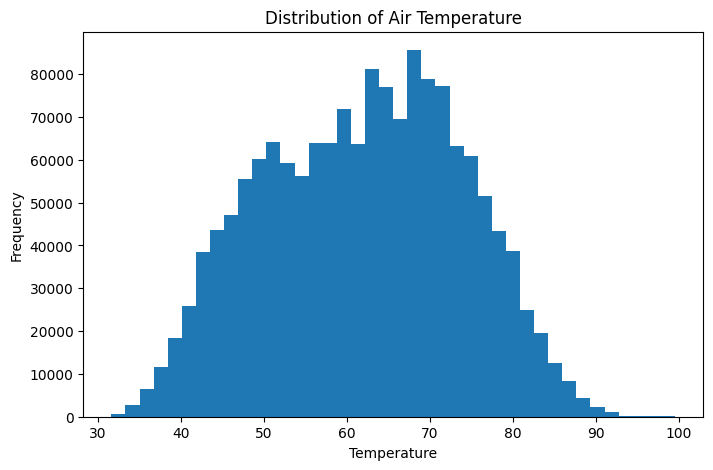

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df_minute['air_temp'], bins=40)

plt.title("Distribution of Air Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

The air temperature follows an approximately normal distribution with most observations concentrated between 50°F and 75°F. Extreme temperatures occur infrequently, indicating that the dataset is dominated by moderate weather conditions.

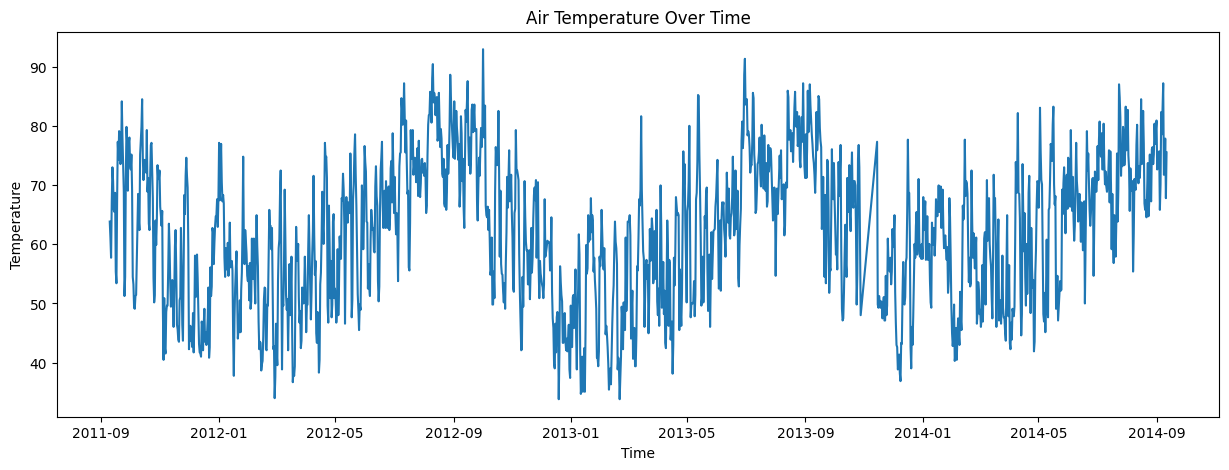

In [9]:
sample = df_minute.iloc[::1000]

plt.figure(figsize=(15,5))

plt.plot(sample['hpwren_timestamp'],
         sample['air_temp'])

plt.title("Air Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.show()

There is a clear seasonal pattern.Temperature rises during the middle of each year and falls toward the beginning and end.The time series exhibits strong seasonal variation, with higher temperatures during summer months and lower temperatures during winter months. This indicates that temporal features such as month and hour are likely to improve prediction accuracy.

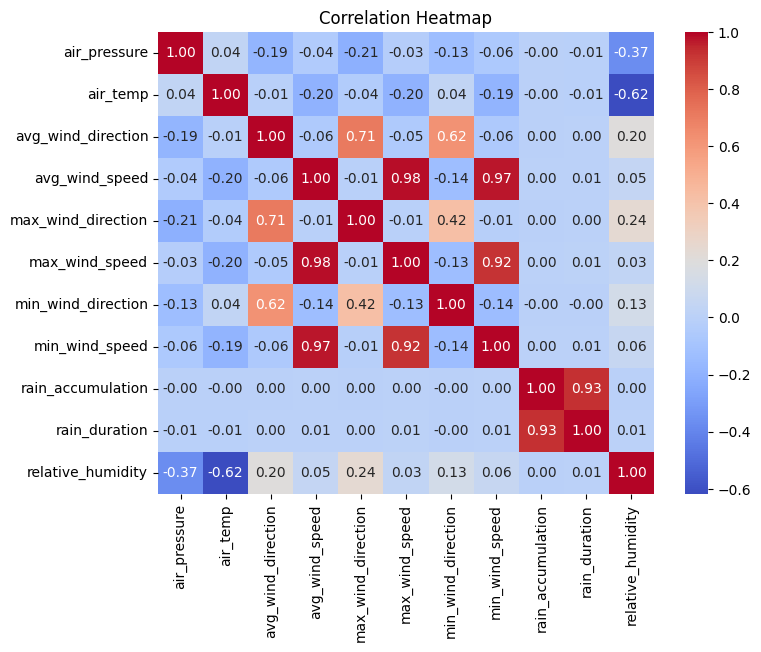

In [10]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df_minute.drop(columns=['rowID']).corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


Rain accumulation and rain duration are also strongly correlated.The correlation analysis shows that relative humidity has the strongest relationship with air temperature (r = -0.62). Wind speed variables exhibit high multicollinearity, while rain accumulation and rain duration are also strongly correlated.

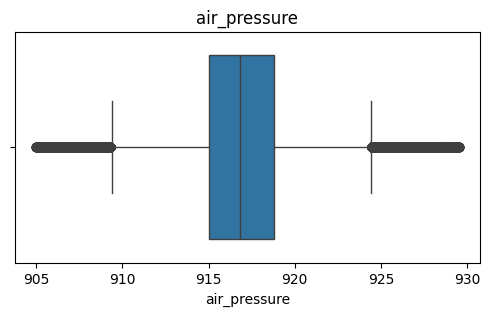

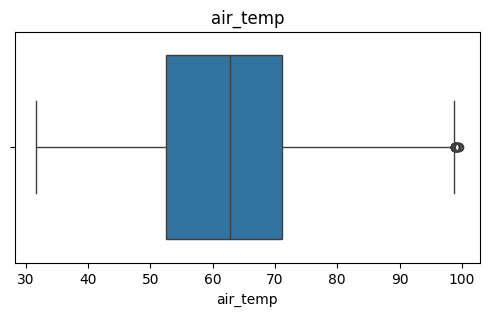

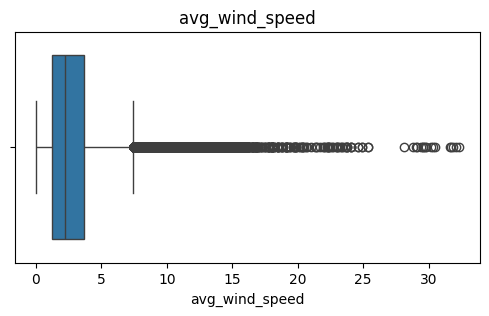

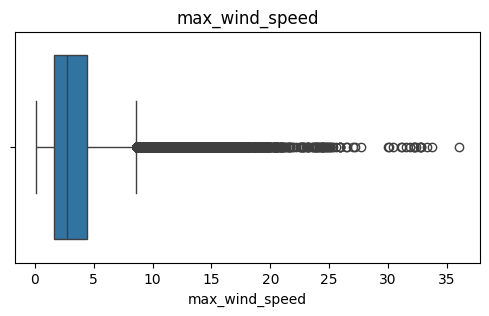

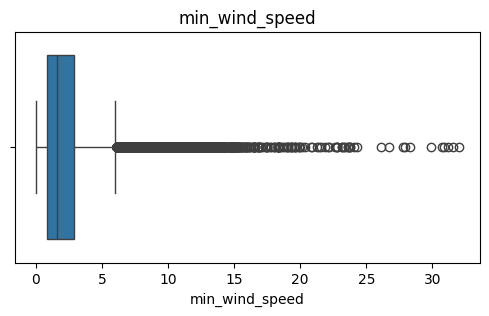

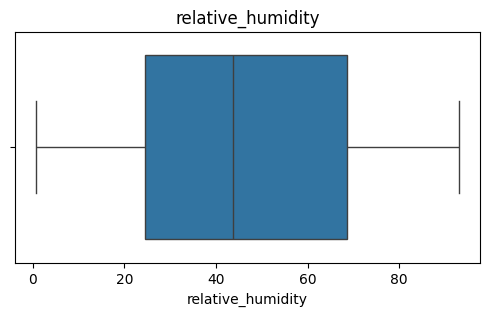

In [11]:
numeric_cols = [
    'air_pressure',
    'air_temp',
    'avg_wind_speed',
    'max_wind_speed',
    'min_wind_speed',
    'relative_humidity'
]

for col in numeric_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df_minute[col])

    plt.title(col)

    plt.show()

Wind speed variables contain several high-value observations. These represent genuine weather events rather than data errors and were therefore retained.

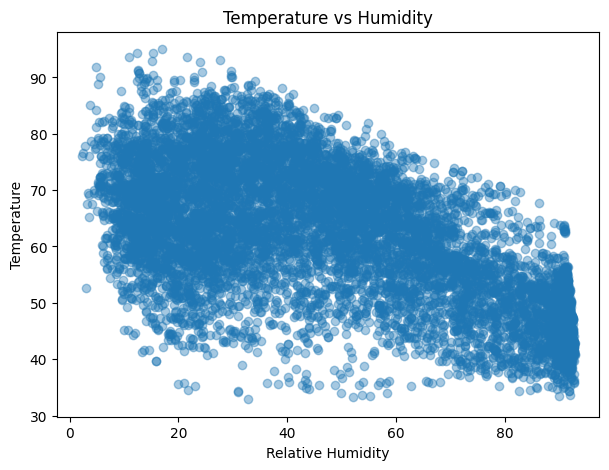

In [12]:
sample = df_minute.sample(10000, random_state=42)

plt.figure(figsize=(7,5))

plt.scatter(
    sample['relative_humidity'],
    sample['air_temp'],
    alpha=0.4
)

plt.xlabel("Relative Humidity")
plt.ylabel("Temperature")

plt.title("Temperature vs Humidity")

plt.show()

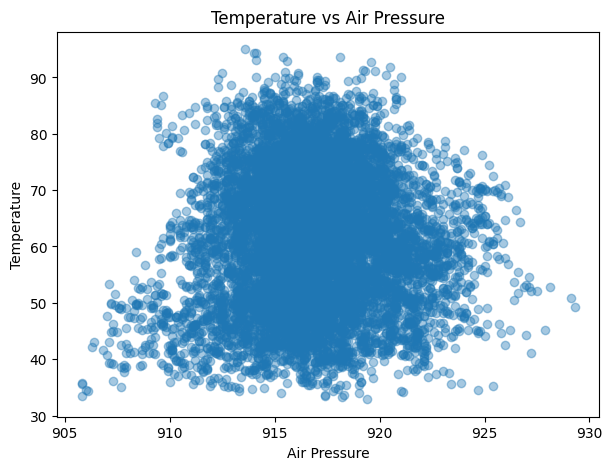

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(
    sample['air_pressure'],
    sample['air_temp'],
    alpha=0.4
)

plt.xlabel("Air Pressure")
plt.ylabel("Temperature")

plt.title("Temperature vs Air Pressure")

plt.show()

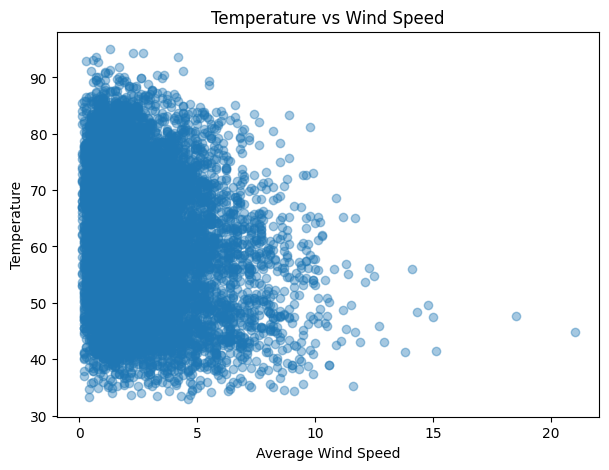

In [14]:
plt.figure(figsize=(7,5))

plt.scatter(
    sample['avg_wind_speed'],
    sample['air_temp'],
    alpha=0.4
)

plt.xlabel("Average Wind Speed")
plt.ylabel("Temperature")

plt.title("Temperature vs Wind Speed")

plt.show()

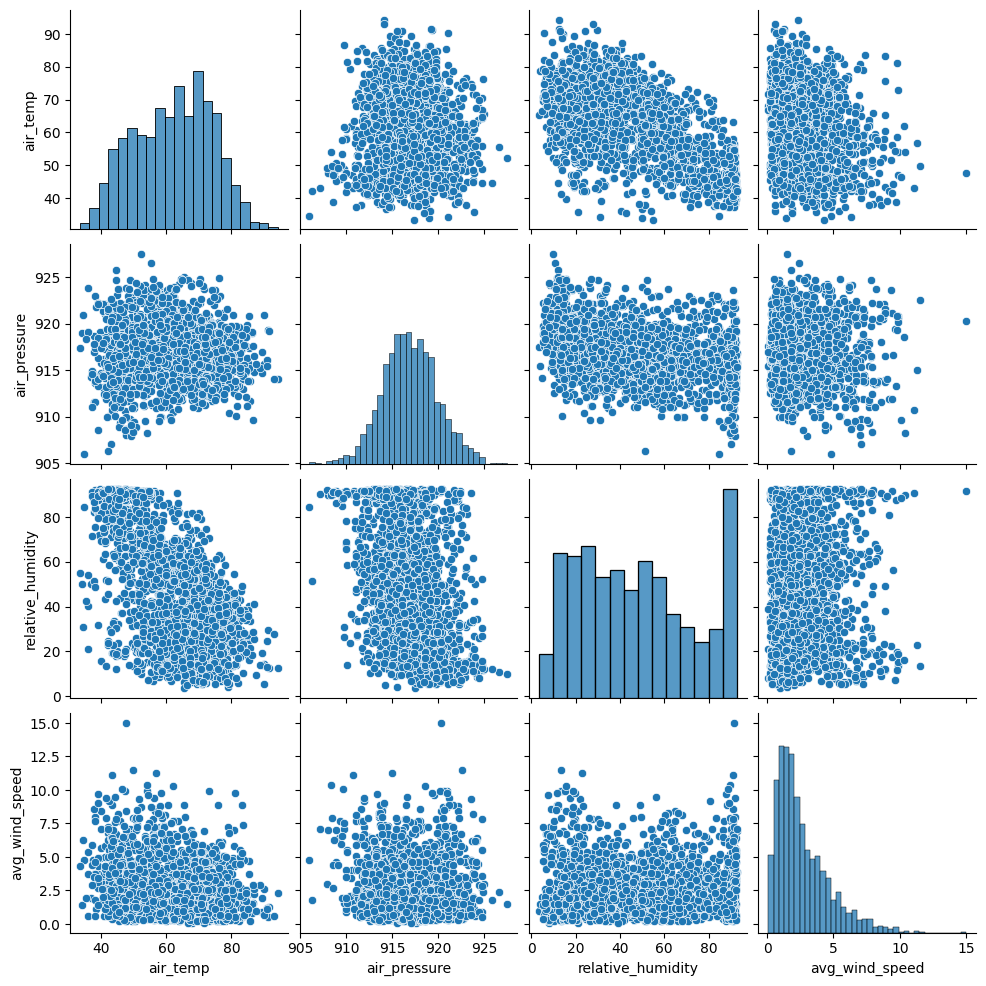

In [15]:
sample = df_minute.sample(2000, random_state=42)

cols = [
    'air_temp',
    'air_pressure',
    'relative_humidity',
    'avg_wind_speed'
]

sns.pairplot(sample[cols])

plt.show()

The strongest visible relationship is between temperature and humidity
This agrees with the correlation coefficient (-0.62).
Pressure appears weakly related.
Wind speed has almost no linear relationship.

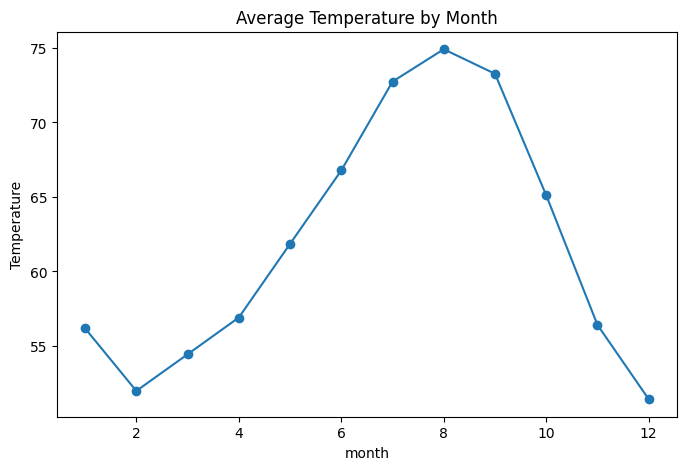

In [16]:
df_minute['month'] = df_minute['hpwren_timestamp'].dt.month
monthly = df_minute.groupby('month')['air_temp'].mean()

plt.figure(figsize=(8,5))

monthly.plot(marker='o')

plt.title("Average Temperature by Month")

plt.ylabel("Temperature")

plt.show()

Average temperature follows a clear annual seasonal cycle, peaking during July and August and reaching minimum values during winter months.

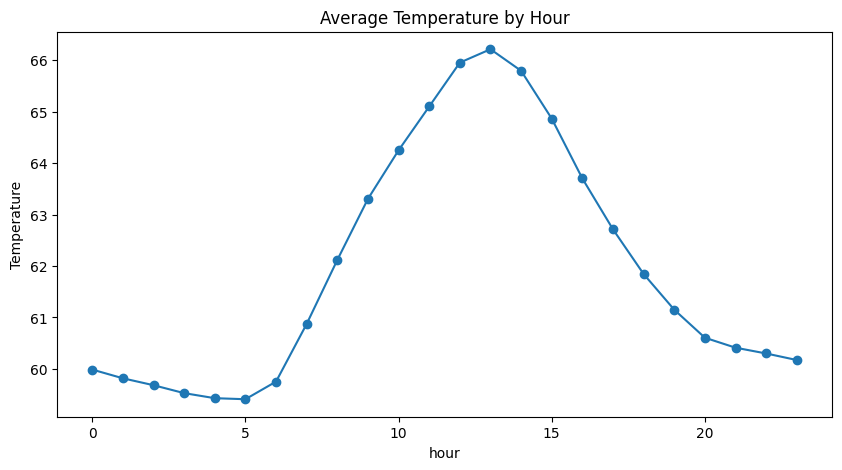

In [17]:
df_minute['hour'] = df_minute['hpwren_timestamp'].dt.hour

hourly = df_minute.groupby('hour')['air_temp'].mean()

plt.figure(figsize=(10,5))

hourly.plot(marker='o')

plt.title("Average Temperature by Hour")

plt.ylabel("Temperature")

plt.show()

Daily temperature follows the expected diurnal cycle, with the lowest temperatures occurring before sunrise and the highest temperatures occurring during the early afternoon.

In [18]:
df_minute.describe().T

,count,mean,min,25%,50%,75%,max,std
rowID,1554044.0,803668.261354,1.0,421247.75,810022.5,1198566.25,1587256.0,457671.915826
hpwren_timestamp,1554044,2013-03-07 23:03:35.862841,2011-09-10 00:01:49,2012-06-06 10:23:58,2013-03-03 10:09:19,2013-12-14 17:49:21,2014-09-10 23:59:29,NaN
air_pressure,1554044.0,916.893481,905.0,915.0,916.8,918.8,929.5,3.05143
air_temp,1554044.0,61.957469,31.64,52.52,62.78,71.06,99.5,11.934428
avg_wind_direction,1554044.0,160.820379,0.0,61.0,181.0,216.0,359.0,95.863546
avg_wind_speed,1554044.0,2.69618,0.0,1.2,2.2,3.7,32.3,2.009796
max_wind_direction,1554044.0,162.161512,0.0,67.0,186.0,221.0,359.0,92.922935
max_wind_speed,1554044.0,3.307594,0.1,1.6,2.7,4.4,36.0,2.362485
min_wind_direction,1554044.0,166.03638,0.0,72.0,179.0,213.0,359.0,98.319163
min_wind_speed,1554044.0,2.066754,0.0,0.8,1.6,2.9,32.0,1.701727


<h2>ML - Pipeline

In [20]:
import numpy as np

#  timestamp = datetime
df_minute['hpwren_timestamp'] = pd.to_datetime(df_minute['hpwren_timestamp'])

# Calendar features
df_minute['year'] = df_minute['hpwren_timestamp'].dt.year
df_minute['month'] = df_minute['hpwren_timestamp'].dt.month
df_minute['day'] = df_minute['hpwren_timestamp'].dt.day
df_minute['hour'] = df_minute['hpwren_timestamp'].dt.hour
df_minute['minute'] = df_minute['hpwren_timestamp'].dt.minute
df_minute['dayofweek'] = df_minute['hpwren_timestamp'].dt.dayofweek
df_minute['dayofyear'] = df_minute['hpwren_timestamp'].dt.dayofyear

In [21]:
# make features cyclical 

## Hour
df_minute['hour_sin'] = np.sin(2*np.pi*df_minute['hour']/24)
df_minute['hour_cos'] = np.cos(2*np.pi*df_minute['hour']/24)

## Month
df_minute['month_sin'] = np.sin(2*np.pi*df_minute['month']/12)
df_minute['month_cos'] = np.cos(2*np.pi*df_minute['month']/12)

## Day of Year
df_minute['dayofyear_sin'] = np.sin(2*np.pi*df_minute['dayofyear']/365)
df_minute['dayofyear_cos'] = np.cos(2*np.pi*df_minute['dayofyear']/365)

In [28]:
features = [
    'year',
    'month',
    'day',
    'hour',
    'minute',
    'dayofweek',
    'dayofyear',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'dayofyear_sin',
    'dayofyear_cos',
    'air_pressure',
    'relative_humidity',
    'avg_wind_speed',
    'max_wind_speed',
    'min_wind_speed',
    'rain_accumulation',
    'rain_duration'
]

X = df_minute[features]

y = df_minute['air_temp']

In [29]:
# splitting this way so that data is split in a chronological way. based on data of 3 years it will try to predict data of 1 year.
split = int(len(df_minute) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [31]:
pipelines = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree": Pipeline([
        ("model", DecisionTreeRegressor(
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ])

}

In [32]:
results = []

for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [33]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,3.500971,4.489414,0.820285
0,Linear Regression,3.829313,4.768784,0.797222
2,Random Forest,4.715033,6.029525,0.675830
1,Decision Tree,5.175712,6.531780,0.619575


In [34]:
import joblib

best_pipeline = pipelines["Gradient Boosting"]

joblib.dump(best_pipeline, "temperature_model.pkl")

['temperature_model.pkl']